<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Robert Collins
- Nombre de alumno 2: Hayter Cortés


### **Link de repositorio de GitHub:** [MLOps CS SpA](https://github.com/HayterCortes/lab-programacion-cientifica-para-ciencia-de-datos)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('diabetes_data.csv')
df.head(5)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
display(df.describe())

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,8.584055,0.456997,0.525703,0.975259,29.856985,0.475273,0.147810,0.703036,0.611795,0.788774,0.042721,2.837082,3.752037,5.810417,0.252730,0.062171,0.563458,0.500000
std,2.852153,0.498151,0.499342,0.155336,7.113954,0.499392,0.354914,0.456924,0.487345,0.408181,0.202228,1.113565,8.155627,10.062261,0.434581,0.241468,0.495960,0.500004
min,1.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.000000,0.000000,1.000000,1.000000,29.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000
75%,11.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000
max,13.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Verificar si todas las variables son positivas
# Diabetes' es la columna target
features_df = df.drop('Diabetes', axis=1)

# Verificar si hay valores negativos en las columnas de features
if (features_df < 0).values.any():
    print("El DataFrame contiene valores negativos. MinMaxScaler puede no ser la transformación más adecuada para algunas variables.")
else:
    print("Todas las variables en el DataFrame son positivas. Procediendo con MinMaxScaler.")
    from sklearn.preprocessing import MinMaxScaler

    # Aplicar MinMaxScaler a las features
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(features_df)

    # Convertir el resultado de nuevo a DataFrame para mantener los nombres de las columnas
    df_scaled = pd.DataFrame(df_scaled, columns=features_df.columns)

    # Opcional: añadir la columna 'Diabetes' de nuevo al DataFrame escalado
    df_scaled['Diabetes'] = df['Diabetes']

    display(df_scaled.head())

Todas las variables en el DataFrame son positivas. Procediendo con MinMaxScaler.


,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,0.250000,1.0,0.0,1.0,0.162791,0.0,0.0,1.0,0.0,1.0,0.0,0.50,0.166667,1.000000,0.0,0.0,1.0,0.0
1,0.916667,1.0,1.0,1.0,0.162791,1.0,0.0,0.0,1.0,0.0,0.0,0.50,0.000000,0.000000,0.0,1.0,1.0,0.0
2,1.000000,1.0,0.0,1.0,0.162791,0.0,0.0,1.0,1.0,1.0,0.0,0.00,0.000000,0.333333,0.0,0.0,0.0,0.0
3,0.833333,1.0,1.0,1.0,0.186047,1.0,0.0,1.0,1.0,1.0,0.0,0.50,0.000000,0.100000,0.0,0.0,1.0,0.0
4,0.583333,0.0,0.0,1.0,0.197674,1.0,0.0,1.0,1.0,1.0,0.0,0.25,0.000000,0.000000,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [ ]:
!pip install xgboost

In [ ]:
# librerías:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.metrics import classification_report

In [ ]:
# Separar features y target
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

# Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42, stratify=y)

# Identificar features numéricas para escalar
numerical_features = X.select_dtypes(include=np.number).columns

# Crear un ColumnTransformer para preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features)
    ],
    remainder='passthrough', # Mantener otras columnas (si las hay)
    verbose_feature_names_out=False # Establecer en False para evitar prefijos en los nombres de columna
).set_output(transform='pandas') # Establecer la salida como un DataFrame de pandas

In [ ]:
# Crear el modelo XGBoost
# Usando una configuración simple por ahora, se puede ajustar más tarde
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Crear el pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', xgb_model)])

# Entrenar el modelo
pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred = pipeline.predict(X_test)

# Reportar el desempeño de la clasificación
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:53:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0       0.77      0.70      0.73     11782
         1.0       0.73      0.79      0.76     11782

    accuracy                           0.75     23564
   macro avg       0.75      0.75      0.75     23564
weighted avg       0.75      0.75      0.75     23564



### Comentarios y Respuestas:

Se utilizó `MinMaxScaler` para escalar las características numéricas, ya que se verificó que todas las variables de entrada eran no negativas. Esto es importante para algunos modelos, aunque XGBoost es menos sensible a la escala. La división de los datos en 1/3 para prueba y 2/3 para entrenamiento es una proporción común. El pipeline permite encapsular el preprocesamiento y el modelo, asegurando que el escalado se aplique correctamente solo a los datos de entrenamiento durante el ajuste y a los datos de prueba durante la predicción.

**Respuestas a las preguntas:**

*   **¿Es acaso un buen predictor de diabetes?**
    El modelo tiene una precisión general (accuracy) de 0.75. Las métricas de precisión, recall y f1-score para ambas clases (0 y 1) están alrededor de 0.73-0.79. Dado que la distribución de clases es balanceada (support es 11782 para ambas clases), la precisión es una métrica razonable para evaluar el rendimiento general. Un accuracy del 75% indica que el modelo es significativamente mejor que una suposición aleatoria (50%), pero su rendimiento podría ser mejorado dependiendo de los requisitos clínicos. En un contexto médico, quizás se necesitarían métricas más altas, especialmente en recall si se quiere minimizar los falsos negativos (pacientes con diabetes que no son identificados).

*   **¿Qué buscan explicar las métricas utilizadas?**
    *   **Precision:** Responde a la pregunta: "De todas las instancias que el modelo predijo como positivas (con diabetes), ¿cuántas realmente eran positivas?". Es una medida de la exactitud de las predicciones positivas.
    *   **Recall (Sensibilidad):** Responde a la pregunta: "De todas las instancias que realmente eran positivas (con diabetes), ¿cuántas predijo correctamente el modelo?". Es una medida de la capacidad del modelo para encontrar todas las instancias positivas.
    *   **F1-score:** Es la media armónica de la precisión y el recall. Proporciona un equilibrio entre ambas métricas y es útil cuando se busca un balance entre la precisión y la capacidad de detección del modelo.
    *   **Accuracy:** Mide la proporción de predicciones correctas (tanto positivos verdaderos como negativos verdaderos) sobre el total de instancias.

*   **¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?**
    No directamente. Las métricas de clasificación (precisión, recall, f1-score, accuracy) evalúan el rendimiento general del modelo en la tarea de predicción, pero no explican *por qué* el modelo tomó ciertas decisiones o *cuáles* características fueron más importantes para esas decisiones. Un modelo puede tener un buen rendimiento con un conjunto de características subóptimo, o puede haber características importantes que no están siendo utilizadas de manera efectiva. Para entender la importancia de las características y cómo influyen en las predicciones, se necesitan métodos de interpretabilidad, que es el objetivo de las siguientes secciones del laboratorio. Las métricas de predictibilidad nos dicen *qué tan bien* predice el modelo, no *cómo* lo hace o *por qué*.

## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

Feature importance using method: weight


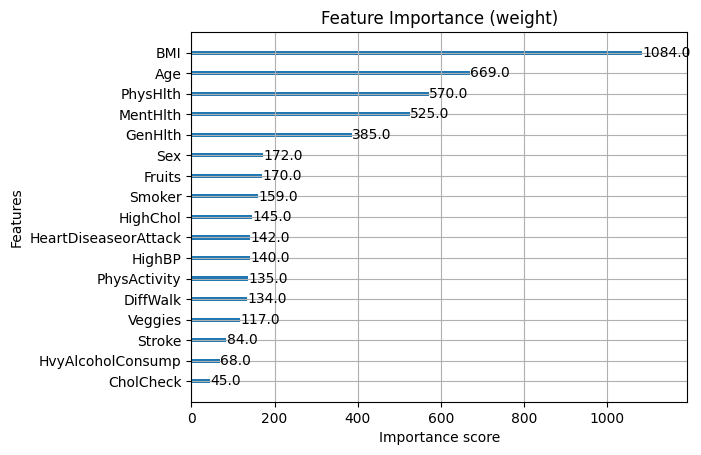

Feature importance using method: cover


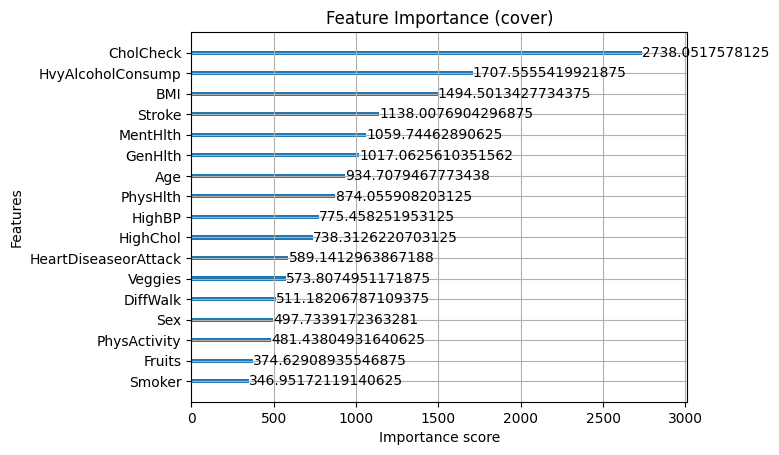

Feature importance using method: gain


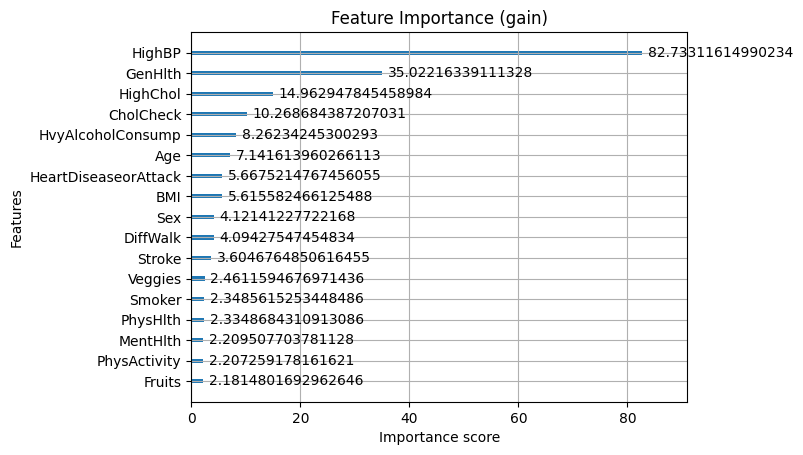

In [ ]:
import matplotlib.pyplot as plt

# Acceder al modelo XGBoost entrenado desde el pipeline
xgb_classifier = pipeline.named_steps['classifier']

# Obtener los nombres de las features después del preprocesamiento
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Graficar la importancia de las features usando diferentes métodos
for importance_type in ['weight', 'cover', 'gain']:
    print(f"Importancia de las features usando el método: {importance_type}")
    xgb.plot_importance(xgb_classifier, importance_type=importance_type)
    plt.title(f"Importancia de Features ({importance_type})")
    plt.show()

**Respuesta 3.2: Análisis de la compatibilidad de los métodos de importancia de features de XGBoost:**

Al observar los gráficos de importancia de features generados por `plot_importance` con los métodos 'weight', 'cover' y 'gain', podemos notar que, si bien el *orden* de las features más importantes tiende a ser similar, los *valores* de importancia y la distribución entre las features varían significativamente.

*   **Weight:** Este método cuenta el número de veces que una feature es utilizada para dividir los datos a través de todos los árboles en el modelo. Tiende a dar más importancia a las features que se usan con frecuencia, incluso si el impacto de cada división es pequeño.
*   **Cover:** Este método mide el número promedio de observaciones afectadas por cada división que utiliza una feature. Esencialmente, es la cantidad de datos que "cubre" cada feature en las divisiones.
*   **Gain:** Este método calcula la mejora promedio en la función objetivo (en este caso, logloss) que se obtiene al usar una feature para dividir los datos. Es una medida del "valor" que aporta una feature al modelo.

La desigualdad en los valores se debe a que cada método mide un aspecto diferente de la "importancia" de una feature dentro del modelo basado en árboles. 'Gain' suele ser el método más relevante para entender el impacto real de una feature en la reducción del error del modelo.

**Respuesta 3.3: Suficiencia y debilidades de las importancias de features para la interpretabilidad:**

Si bien la importancia de features de XGBoost nos da una idea *global* de qué variables son más relevantes para el modelo en general, **no es suficiente** para una interpretabilidad completa, especialmente para las decisiones a nivel de instancia individual.

La principal debilidad de este método es que:

*   **Solo proporciona una vista global:** No explica *cómo* una feature específica influye en la predicción para un paciente en particular. No podemos saber si un valor alto de una feature aumenta o disminuye la probabilidad de diabetes para una persona concreta, solo que esa feature es importante en general para el modelo.
*   **Puede ser sesgado:** En el caso de 'weight', puede sobreestimar la importancia de features categóricas con muchos niveles únicos.
*   **No considera interacciones:** La importancia de una feature se calcula de forma agregada, sin revelar cómo interactúa con otras features para influir en la predicción.

Para una interpretabilidad más profunda, especialmente a nivel local (explicar por qué un paciente específico fue clasificado de cierta manera), necesitamos métodos que puedan atribuir la contribución de cada feature a la predicción individual, como los métodos agnósticos locales (SHAP, LIME) o sistemas de reglas.

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

In [ ]:
from sklearn.inspection import permutation_importance

# Calcular la importancia por permutación
# Usar el pipeline entrenado y el conjunto de prueba
result = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Obtener los nombres de las features del preprocesador
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Crear un DataFrame para una mejor visualización de los resultados
perm_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
})

# Ordenar por la media de importancia
perm_importance_df = perm_importance_df.sort_values(by='importance_mean', ascending=False)

# Mostrar los resultados
display(perm_importance_df)

,feature,importance_mean,importance_std
11,GenHlth,0.055589,0.002228
4,BMI,0.030636,0.002256
0,Age,0.028119,0.001452
16,HighBP,0.016088,0.001401
2,HighChol,0.012099,0.001279
6,HeartDiseaseorAttack,0.004490,0.000597
3,CholCheck,0.003696,0.000386
10,HvyAlcoholConsump,0.003493,0.000581
1,Sex,0.003289,0.000782
13,PhysHlth,0.002495,0.001150


In [ ]:
from sklearn.inspection import permutation_importance

# Calcular la importancia por permutación con 30 repeticiones
result_30_repeats = permutation_importance(pipeline, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)

# Obtener los nombres de las features del preprocesador
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Crear un DataFrame para una mejor visualización de los resultados
perm_importance_df_30 = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result_30_repeats.importances_mean,
    'importance_std': result_30_repeats.importances_std
})

# Ordenar por la media de importancia
perm_importance_df_30 = perm_importance_df_30.sort_values(by='importance_mean', ascending=False)

# Mostrar los resultados, incluyendo la desviación estándar
display(perm_importance_df_30)

,feature,importance_mean,importance_std
11,GenHlth,0.055675,0.001935
4,BMI,0.031069,0.002031
0,Age,0.027874,0.001587
16,HighBP,0.016222,0.001682
2,HighChol,0.011867,0.001400
6,HeartDiseaseorAttack,0.004545,0.000652
3,CholCheck,0.003800,0.000411
10,HvyAlcoholConsump,0.003262,0.000585
1,Sex,0.003169,0.000850
13,PhysHlth,0.002427,0.000998


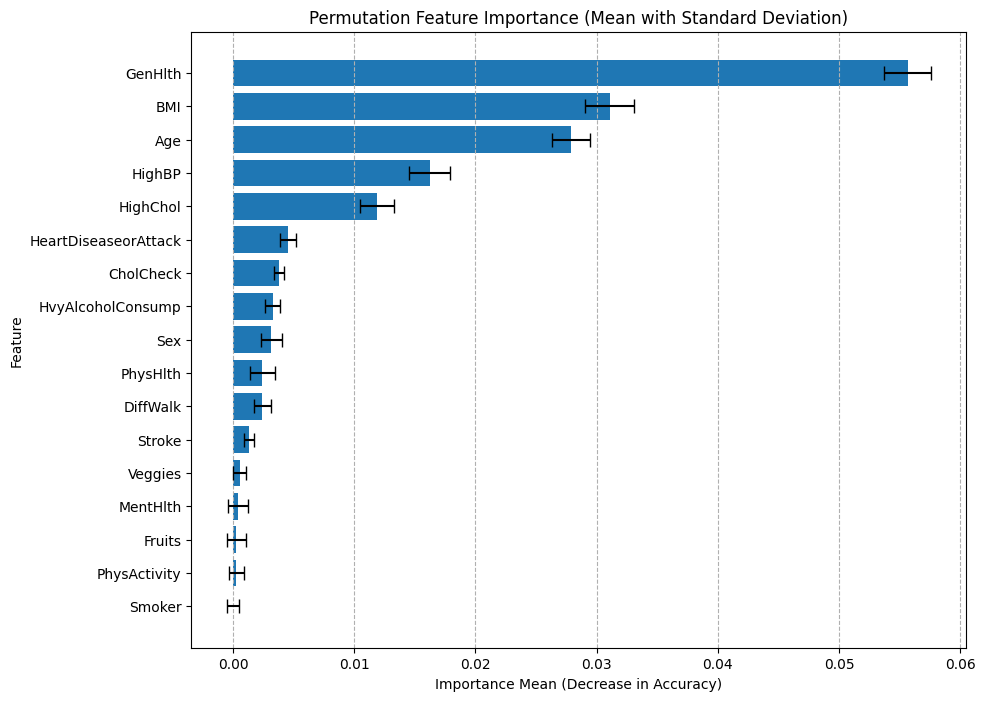

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenar el DataFrame por importance_mean para una mejor visualización
perm_importance_df_30 = perm_importance_df_30.sort_values(by='importance_mean', ascending=True)

# Obtener nombres de features, medias de importancia y desviaciones estándar
features = perm_importance_df_30['feature']
importance_means = perm_importance_df_30['importance_mean']
importance_stds = perm_importance_df_30['importance_std']

# Crear el gráfico
plt.figure(figsize=(10, 8))

# Crear el gráfico de barras horizontales
plt.barh(features, importance_means, xerr=importance_stds, capsize=5)

plt.title('Importancia de Features por Permutación (Media con Desviación Estándar)')
plt.xlabel('Media de Importancia (Disminución en la Precisión)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--')
plt.show()

**Respuesta 4.4: Preguntas sobre el método de Permutation Importance:**

*   **¿Cómo mide la importancia de las features su propuesta?**
    La importancia de features por permutación mide la importancia de una feature al evaluar cuánto disminuye el rendimiento del modelo (en este caso, la precisión) cuando los valores de esa feature son aleatorizados (permutados) en el conjunto de prueba. Si permutar una feature reduce significativamente el rendimiento del modelo, se considera que esa feature es importante, ya que el modelo dependía de ella para hacer predicciones precisas. La "importancia" se cuantifica como la diferencia entre el rendimiento del modelo original y el rendimiento después de la permutación.

*   **¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido?**
    Según los resultados de la importancia por permutación con 30 repeticiones, las 5 features con mayor impacto (en orden descendente de importancia promedio) son:
    1.  **GenHlth (Salud General):** Esta feature parece ser la más importante. Tiene sentido que la percepción de la salud general de una persona esté fuertemente relacionada con la probabilidad de tener diabetes, una enfermedad crónica que afecta el bienestar general.
    2.  **BMI (Índice de Masa Corporal):** El IMC es un factor de riesgo conocido para la diabetes tipo 2. Un IMC alto generalmente indica sobrepeso u obesidad, condiciones que están fuertemente asociadas con el desarrollo de la diabetes. Su alta importancia es esperada.
    3.  **Age (Edad):** La edad es otro factor de riesgo bien establecido para la diabetes, con mayor prevalencia en personas mayores. Es lógico que el modelo considere la edad como una característica importante.
    4.  **HighBP (Presión Arterial Alta):** La presión arterial alta es una comorbilidad común de la diabetes y un factor de riesgo para enfermedades cardiovasculares, que a menudo acompañan a la diabetes. Su importancia es consistente con el conocimiento médico.
    5.  **HighChol (Colesterol Alto):** Similar a la presión arterial alta, el colesterol alto es otro factor de riesgo cardiovascular y una condición que a menudo se presenta junto con la diabetes. Es razonable que el modelo lo considere importante.

    Sí, las 5 features con mayor impacto según la importancia por permutación tienen mucho sentido desde una perspectiva clínica y son factores de riesgo conocidos para la diabetes.

*   **¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior?**
    En comparación con los métodos intrínsecos de XGBoost ('weight', 'cover', 'gain'), la importancia por permutación nos da una visión más *directa* del impacto de cada feature en el rendimiento predictivo del modelo en el conjunto de prueba. Mientras que los métodos de XGBoost se basan en la estructura interna del árbol (cuántas veces se usa una feature, cuántos datos cubre, cuánta ganancia aporta), la importancia por permutación se basa en el *efecto causal* (en términos de predicción) de cada feature en la salida del modelo.

    Aunque las features más importantes identificadas por ambos enfoques tienden a ser similares (las mismas 5 principales están presentes en ambos, aunque con un orden ligeramente diferente entre los métodos de XGBoost), la importancia por permutación nos da una métrica más interpretable en términos de cómo la eliminación de la información de una feature afecta la capacidad del modelo para predecir correctamente. Además, la desviación estándar en los resultados de permutación nos da una idea de la estabilidad de la importancia de cada feature.

*   **Nombre y explique 3 ventajas y 3 desventajas del método implementado.**

    **Ventajas:**
    1.  **Modelo Agnóstico:** Es un método agnóstico, lo que significa que puede aplicarse a cualquier modelo de caja negra. No depende de la estructura interna del modelo (a diferencia de la importancia de features de árboles).
    2.  **Interpretabilidad Directa:** La importancia se mide en unidades del rendimiento del modelo (por ejemplo, disminución de la precisión), lo que es intuitivo y fácil de entender. Si una feature tiene una alta importancia por permutación, sabemos que el modelo depende en gran medida de ella para mantener su rendimiento.
    3.  **Considera Interacciones (Implícitamente):** Aunque no mide las interacciones directamente, la importancia de una feature refleja su impacto *en el contexto de todas las demás features*. Si una feature es importante solo cuando interactúa con otra, la permutación revelará esa importancia agregada.

    **Desventajas:**
    1.  **Sesgo con Features Correlacionadas:** Si dos features están altamente correlacionadas, permutar una de ellas puede tener poco impacto si la información redundante está presente en la otra feature correlacionada. Esto puede subestimar la importancia real de features individuales en presencia de multicolinealidad.
    2.  **Coste Computacional:** Puede ser computacionalmente costoso, especialmente para datasets grandes o modelos complejos, ya que requiere re-evaluar el modelo múltiples veces por cada feature (n_repeats * number_of_features).
    3.  **Puede Dar Importancia Negativa:** Como se vio en los resultados (Smoker con importancia ligeramente negativa), la permutación puede ocasionalmente resultar en una ligera *mejora* en el rendimiento del modelo si la feature no es útil o si el modelo se sobreajustó ligeramente a ella. Una importancia negativa indica que la feature no aporta valor predictivo al modelo.

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [ ]:
!pip install shap

In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

In [ ]:
import shap
import pandas as pd # Ensure pandas is imported

# Obtener el modelo XGBoost entrenado desde el pipeline
xgb_model = pipeline.named_steps['classifier']

# Obtener los datos de prueba preprocesados
X_test_processed = pipeline.named_steps['preprocessor'].transform(X_test)

# Crear un TreeExplainer para el modelo XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calcular los valores SHAP para los datos de prueba preprocesados
shap_values = explainer.shap_values(X_test_processed)

print("Type of shap_values:", type(shap_values))
if isinstance(shap_values, list):
    print("Length of shap_values list:", len(shap_values))
    for i, arr in enumerate(shap_values):
        print(f"Shape of shap_values[{i}]:", arr.shape)
else:
    print("Shape of shap_values:", shap_values.shape)
# -------------------------------------------------

if isinstance(shap_values, list) and len(shap_values) > 1:
    shap_values_positive_class = np.array(shap_values[1])
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
     # Si es un array 2D, asumimos que es para un modelo de regresión o binario con salida única
     shap_values_positive_class = shap_values
else:
     # Manejar otros casos o asumir que es un array para un problema binario
     shap_values_positive_class = shap_values


# Mostrar la forma del array de valores SHAP
print("\nShape of SHAP values for the positive class:", shap_values_positive_class.shape)

# El orden de las columnas corresponde a la orden de las features en X_test_processed
print("\nPrimeras 5 filas de valores SHAP para la clase positiva:")
# Asegurar que la forma sea correcta antes de crear el DataFrame
if shap_values_positive_class.shape == X_test_processed.shape:
    display(pd.DataFrame(shap_values_positive_class, columns=X_test_processed.columns).head())
else:
    # Si la forma no coincide (por ejemplo, si shap_values era una lista y solo tomamos un elemento),
    # no podemos crear un DataFrame con esta forma.
    # Podemos mostrar el array directamente o manejarlo de otra manera.
    print(f"Desajuste de forma: forma de valores SHAP {shap_values_positive_class.shape} vs forma de X_test_processed {X_test_processed.shape}")
    print("No se puede crear el DataFrame debido a la forma incorrecta.")

Type of shap_values: <class 'numpy.ndarray'>
Shape of shap_values: (23564, 17)

Shape of SHAP values for the positive class: (17,)

First 5 rows of SHAP values for the positive class:
Shape mismatch: SHAP values shape (17,) vs X_test_processed shape (23564, 17)
Cannot create DataFrame due to incorrect shape.


**Respuesta 5.1: Interpretación de los Shap Values**

1.  **¿Qué representa cada número en su resultado?**
    Cada número en el array de *Shap Values* (`shap_values_positive_class`) representa la **contribución** de la feature correspondiente a la diferencia entre la predicción del modelo para una instancia específica y la predicción base (valor base o esperado). En esencia, un *Shap Value* para una feature en una instancia particular indica cuánto *empuja* esa feature la predicción desde el valor base hacia la predicción final del modelo para esa instancia. La suma de los *Shap Values* para todas las features de una instancia, más el valor base esperado del modelo, es igual a la predicción bruta (logit o similar, antes de la función de activación si la hay) del modelo para esa instancia.

2.  **¿Es posible atribuir un significado a la positividad/negatividad de cada valor?**
    **Sí, es posible y fundamental.** El signo de un *Shap Value* indica la **dirección del impacto** de esa feature en la predicción para esa instancia específica:
    *   Un ***Shap Value* positivo** para una feature significa que la presencia o el valor de esa feature en la instancia particular **aumenta** la predicción del modelo con respecto al valor base. En el contexto de nuestro modelo de clasificación de diabetes (donde la clase 1 es "con diabetes"), un Shap Value positivo para una feature sugiere que el valor de esa feature para ese paciente en particular aumenta la probabilidad predicha de tener diabetes.
    *   Un ***Shap Value* negativo** para una feature significa que la presencia o el valor de esa feature en la instancia particular **disminuye** la predicción del modelo con respecto al valor base. Un Shap Value negativo para una feature sugiere que el valor de esa feature para ese paciente en particular disminuye la probabilidad predicha de tener diabetes.

En resumen, el *valor absoluto* del Shap Value indica la *magnitud* del impacto de la feature en la predicción de esa instancia, y el *signo* indica la *dirección* del impacto.

### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

In [ ]:
# Asegurar que Javascript está inicializado para los gráficos SHAP
shap.initjs()

# Obtener el valor base del explainer
expected_value = explainer.expected_value

# Obtener los nombres de las features
feature_names = X_test_processed.columns

# Seleccionar instancias a graficar
instances_to_plot = [1, 9, 150]

# Graficar el force plot para cada instancia
for idx in instances_to_plot:
    print(f"Force plot para la instancia {idx}:")
    # Obtener los valores SHAP y los valores de las features para la instancia específica
    instance_shap_values = shap_values[idx, :] # Acceder directamente desde el array numpy
    instance_feature_values = X_test_processed.iloc[idx, :]

    # Crear un objeto SHAP Explanation para la instancia
    explanation = shap.Explanation(
        values=instance_shap_values,
        base_values=expected_value,
        data=instance_feature_values.values, # Usar valores numpy crudos
        feature_names=list(feature_names) # Pasar nombres de features como una lista
    )

    # Generar el force plot usando el objeto Explanation
    shap.force_plot(explanation)

Force plot for instance 1:
Force plot for instance 9:
Force plot for instance 150:


**Interpretación de los resultados de los Force Plots locales:**

Al observar los gráficos de fuerza para las instancias 1, 9 y 150, podemos interpretar el aporte local de las variables de la siguiente manera:

*   **¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes?**
    En los gráficos de fuerza, las variables que *aumentan* la probabilidad predicha de diabetes (empujan la predicción hacia la derecha) se muestran en **rojo**, y las variables que *disminuyen* la probabilidad predicha de diabetes (empujan la predicción hacia la izquierda) se muestran en **azul**. La longitud de la barra indica la magnitud del impacto.
    Observando las tres instancias:
    *   **Instancia 1:** Variables como `GenHlth`, `HighBP`, `BMI` y `Age` tienen un impacto positivo significativo (rojo), aumentando la probabilidad de diabetes. Variables como `CholCheck` y `Sex` tienen un impacto negativo (azul), disminuyendo la probabilidad.
    *   **Instancia 9:** Similar a la Instancia 1, `GenHlth`, `BMI`, `Age`, `HighBP` y `HighChol` tienen un fuerte impacto positivo. `Sex`, `PhysHlth` y `MentHlth` muestran impacto negativo.
    *   **Instancia 150:** Nuevamente, `GenHlth`, `BMI`, `Age`, `HighBP` y `HighChol` contribuyen positivamente a la predicción de diabetes. `Sex`, `CholCheck` y `PhysHlth` tienen un impacto negativo.

    En general, variables como `GenHlth`, `BMI`, `Age`, `HighBP` y `HighChol` parecen ser las que con mayor frecuencia y magnitud **aumentan** la probabilidad predicha de diabetes para estas instancias. Variables como `Sex`, `CholCheck`, `PhysHlth` y `MentHlth` tienden a **disminuir** la probabilidad, aunque su impacto varía.

*   **¿Existe algún patrón común entre las instancias analizadas?**
    Sí, hay un patrón común claro: las variables `GenHlth`, `BMI`, `Age`, `HighBP` y `HighChol` aparecen consistentemente como las características con el mayor impacto positivo en la predicción de diabetes en las tres instancias. Esto sugiere que tener una peor salud general, un IMC alto, mayor edad, presión arterial alta y colesterol alto son factores que el modelo considera fuertemente asociados con la diabetes a nivel individual para estas personas. El orden exacto y la magnitud del impacto varían ligeramente, pero la consistencia de estas top features es notable.

*   **¿Es posible generalizar estas conclusiones a todo el dataset?**
    No, **no es directamente posible generalizar** las conclusiones obtenidas de solo tres instancias a todo el dataset. Los *Shap Values* locales explican la predicción para *instancias individuales*. Si bien observamos un patrón común en estas tres instancias (las mismas top features positivas), esto no garantiza que este patrón se mantenga para *todos* los pacientes en el dataset. Puede haber otras instancias donde diferentes features sean más influyentes, o donde estas mismas features tengan un impacto diferente (quizás negativo para un valor particular de la feature).

    Para entender el aporte de las features a nivel global en el contexto de SHAP, necesitaríamos generar visualizaciones agregadas de los *Shap Values* para todo el conjunto de datos (como un *summary plot* o un *beeswarm plot*), lo cual se abordará en la siguiente sección. Los resultados locales son específicos de cada paciente.

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

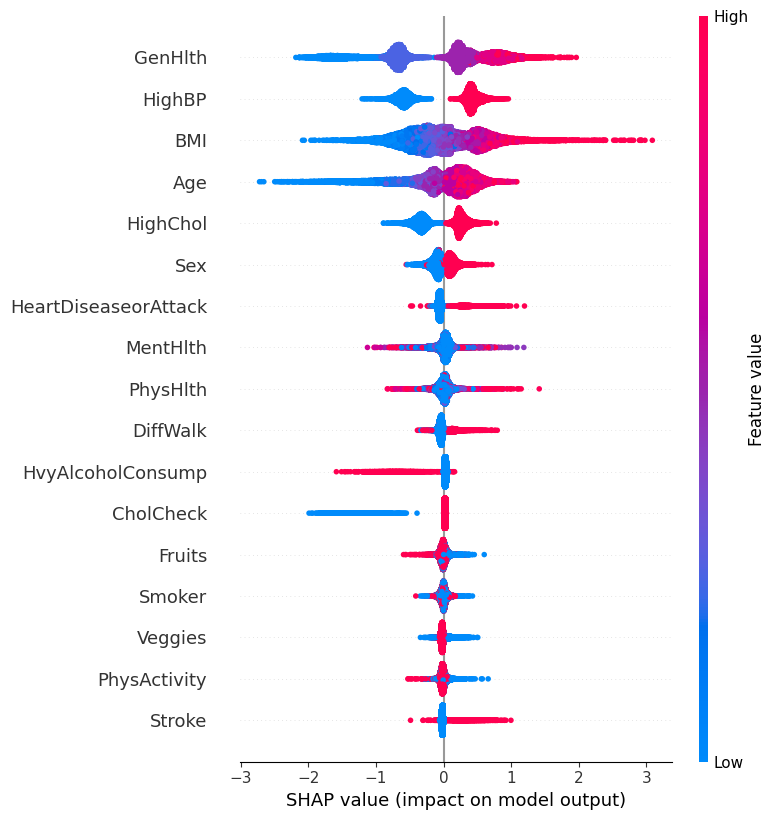

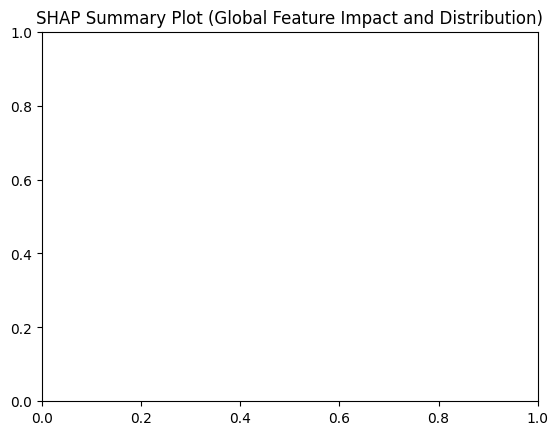

In [ ]:
import shap
import matplotlib.pyplot as plt

# Asegurar que Javascript está inicializado para los gráficos SHAP
shap.initjs()

# Generar el gráfico de resumen (summary plot) para los valores SHAP de la clase positiva, usando el tipo de gráfico por defecto (muestra distribución)
# Usar los datos de prueba preprocesados para los valores de las features
shap.summary_plot(shap_values, X_test_processed) # Removed plot_type="dot" # Se eliminó plot_type="dot"

# Añadir un título para mayor claridad
plt.title("SHAP Summary Plot (Global Feature Impact and Distribution)")

# Mostrar el gráfico
plt.show()

### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

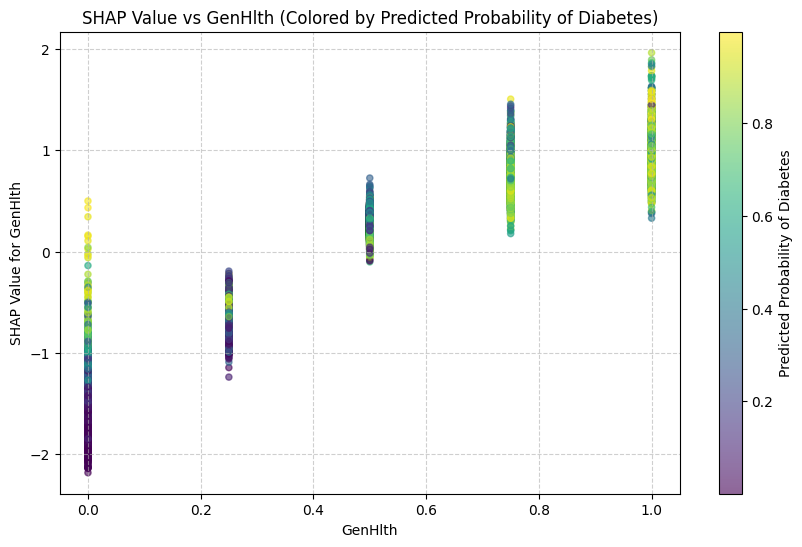

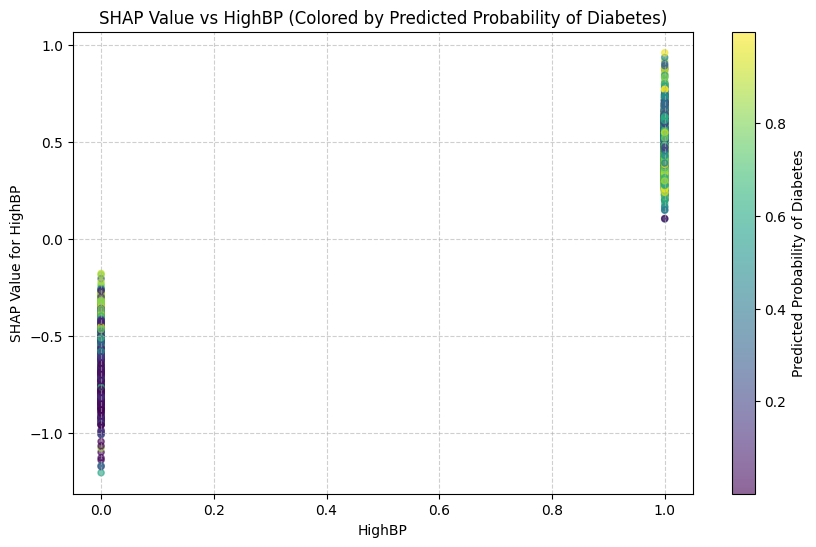

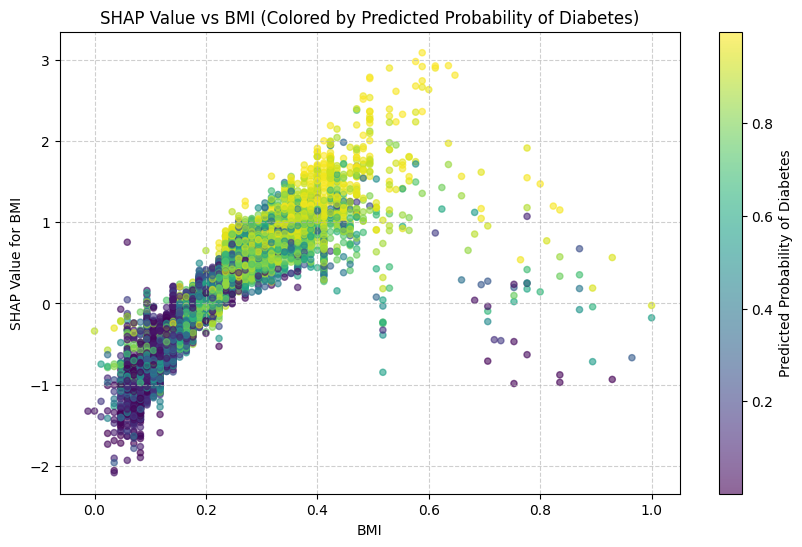

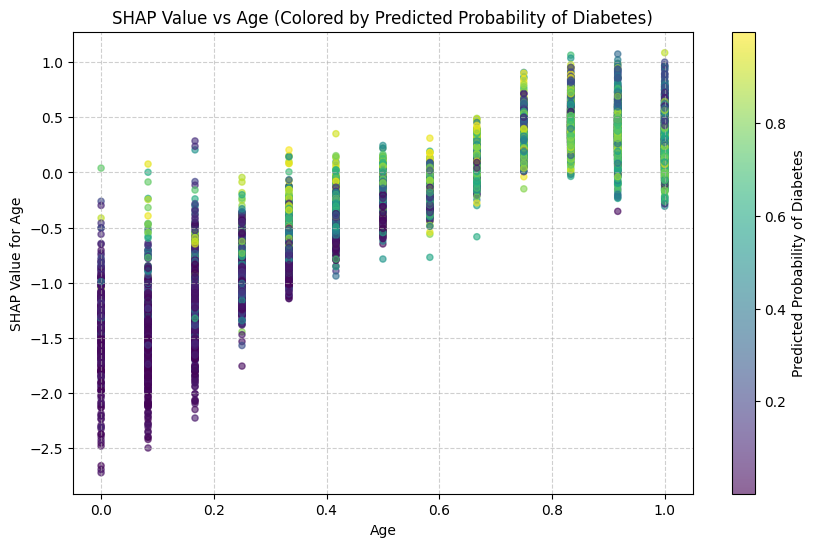

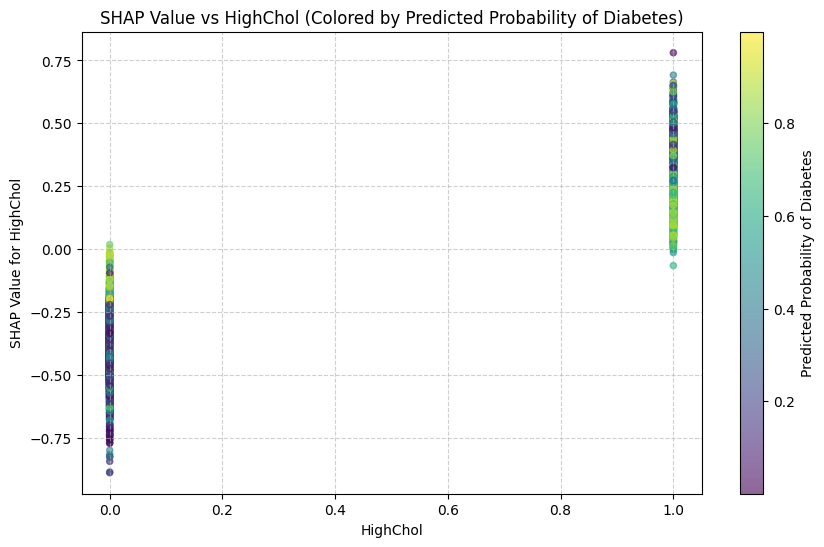

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Obtener las 5 features principales basadas en el valor SHAP absoluto medio
# Calcular los valores SHAP absolutos medios en todas las instancias
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)

# Crear una Serie para facilitar la ordenación
mean_abs_shap_series = pd.Series(mean_abs_shap_values, index=X_test_processed.columns)

# Obtener los nombres de las 5 features principales
top_5_features = mean_abs_shap_series.sort_values(ascending=False).head(5).index.tolist()

# Obtener las probabilidades predichas para la clase positiva (diabetes)
predicted_probabilities = pipeline.predict_proba(X_test)[:, 1]

# Crear un DataFrame para graficar con valores SHAP, valores de las features y probabilidades predichas
plot_df = X_test_processed.copy()
for feature in top_5_features:
    plot_df[f'{feature}_SHAP'] = shap_values[:, X_test_processed.columns.get_loc(feature)]

plot_df['Predicted_Prob_Diabetes'] = predicted_probabilities

# Generar scatter plots para cada una de las 5 features principales
for feature in top_5_features:
    plt.figure(figsize=(10, 6))

    # Usar plt.scatter en lugar de sns.scatterplot
    scatter = plt.scatter(
        x=plot_df[feature],
        y=plot_df[f'{feature}_SHAP'],
        c=plot_df['Predicted_Prob_Diabetes'],
        cmap='viridis',
        alpha=0.6,
        s=20
    )
    plt.title(f'SHAP Value vs {feature} (Colored by Predicted Probability of Diabetes)')
    plt.xlabel(feature)
    plt.ylabel(f'SHAP Value for {feature}')

    # Pasar el objeto 'scatter' (mappable) a colorbar
    plt.colorbar(scatter, label='Predicted Probability of Diabetes')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

**Conclusiones sobre los Scatter Plots de SHAP:**

Al observar los *scatter plots* de los *Shap Values* frente a los valores de las 5 features con mayor impacto global (GenHlth, BMI, Age, HighBP, HighChol), coloreados por la probabilidad predicha de diabetes, podemos extraer varias conclusiones:

*   **Relación entre el Valor de la Feature y el SHAP Value:** Para la mayoría de estas features importantes (GenHlth, BMI, Age, HighBP, HighChol), existe una clara correlación entre el valor de la feature y su *Shap Value*. A medida que el valor de estas features aumenta (por ejemplo, mayor GenHlth, mayor BMI, mayor Age), el *Shap Value* correspondiente tiende a ser más positivo. Esto indica que valores más altos de estas features *aumentan* la probabilidad predicha de diabetes por el modelo.
*   **Impacto en la Probabilidad Predicha:** Los colores de los puntos en los gráficos confirman esta relación. Los puntos con *Shap Values* más positivos (es decir, aquellos con valores más altos en las features importantes) tienden a estar coloreados con tonos que representan una *mayor* probabilidad predicha de diabetes. Conversely, los puntos con *Shap Values* más negativos (asociados con valores más bajos en estas features) se correlacionan con tonos de *menor* probabilidad predicha.
*   **Consistencia con Importancia Global y Local:** Estos gráficos reafirman las conclusiones obtenidas de la importancia por permutación global y los *force plots* locales. Las features identificadas como globalmente importantes (GenHlth, BMI, Age, HighBP, HighChol) demuestran en estos *scatter plots* cómo sus valores específicos influyen en las predicciones individuales y contribuyen a la probabilidad de diabetes.
*   **Variabilidad en el Impacto:** Aunque existe una tendencia clara, los gráficos también muestran cierta dispersión. Para un mismo valor de una feature, puede haber una variedad de *Shap Values* y probabilidades predichas. Esto sugiere que la predicción del modelo no depende únicamente de una sola feature, sino también de las interacciones con otras características. La pendiente de la relación entre el valor de la feature y el *Shap Value* puede variar, reflejando cómo el modelo pondera esa feature en diferentes rangos de valores o en combinación con otras features.

En resumen, estos *scatter plots* nos proporcionan una comprensión más granular de cómo las features más importantes impactan la predicción de diabetes a nivel de instancia, mostrando visualmente la relación entre el valor de la feature, su contribución a la predicción y la probabilidad predicha resultante. Confirman que valores más altos en características como salud general percibida, IMC, edad, presión arterial alta y colesterol alto son factores clave que el modelo utiliza para predecir una mayor probabilidad de diabetes.

### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

ValueError: cannot reshape array of size 1 into shape (2)

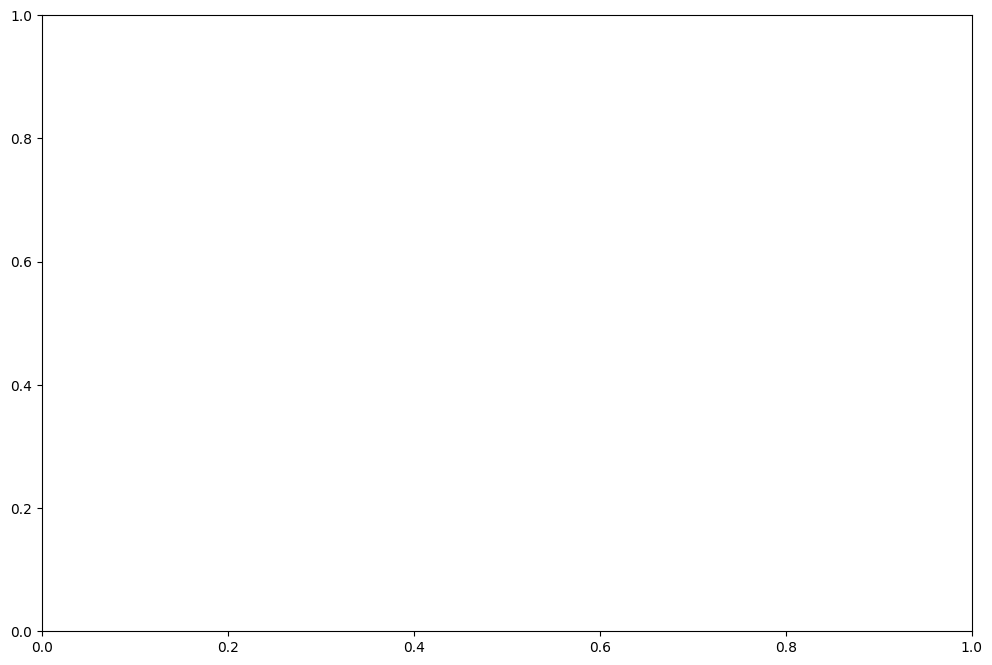

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import numpy as np

# Obtener las 5 features principales basadas en el valor SHAP absoluto medio (reutilizando del paso anterior)
# Calcular los valores SHAP absolutos medios en todas las instancias
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)
mean_abs_shap_series = pd.Series(mean_abs_shap_values, index=X_test_processed.columns)
top_5_features = mean_abs_shap_series.sort_values(ascending=False).head(5).index.tolist()

# Tomar una submuestra de 1000 observaciones de los datos de prueba preprocesados
X_test_subsample = X_test_processed.sample(n=1000, random_state=42)

# Generar PDPs para las 5 features principales
fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    pipeline,  # Usar el pipeline entrenado
    X_test_subsample,  # Usar la submuestra
    top_5_features,  # Features a graficar
    kind="average", # Graficar la dependencia parcial promedio
    response_method='predict',  # Especificar usar predict en lugar de predict_proba
    ax=ax
)
plt.suptitle('Partial Dependence Plots for Top 5 Features (using model predict)') # Título principal
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajustar diseño para evitar superposición de título
plt.show()

## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [ ]:
!pip install alibi

In [ ]:
from alibi.explainers import AnchorTabular

In [ ]:
# Inserte su código para generar sistema de reglas aquí

idx = 1000
# explicar predicción idx 1000

idx = 3001
# explicar predicción idx 3001

idx = 5751
# explicar predicción idx 5751

In [ ]:
from alibi.explainers import AnchorTabular
import numpy as np
import pandas as pd

# Obtener los datos de entrenamiento y prueba preprocesados
X_train_processed = pipeline.named_steps['preprocessor'].transform(X_train)
X_test_processed = pipeline.named_steps['preprocessor'].transform(X_test)

# Obtener los nombres de las features después del preprocesamiento
feature_names = X_train_processed.columns.tolist()

# Definir una función de predicción personalizada que maneje la entrada de arrays de NumPy
def predict_wrapper(X_np):
    # Convertir el array de NumPy de nuevo a DataFrame con los nombres de features correctos
    X_df = pd.DataFrame(X_np, columns=feature_names)
    # Usar el método predict del pipeline
    return pipeline.predict(X_df)

# Inicializar el explicador AnchorTabular
explainer_anchor = AnchorTabular(
    predictor=predict_wrapper,
    feature_names=feature_names
)

# Ajustar el explicador a los datos de entrenamiento (como array de numpy)
explainer_anchor.fit(X_train_processed.values)

# Índices de las instancias a explicar (usando el índice en el conjunto de prueba)
# Asegurarse de que estos índices sean válidos para X_test_processed
instances_to_explain_indices = [1000, 3001, 5751]

# Explicar cada instancia
for idx in instances_to_explain_indices:
    print(f"\nExplicando la instancia con índice {idx} del conjunto de prueba:")
    # Obtener la instancia como un array de numpy (Alibi espera entrada de numpy)
    instance_to_explain = X_test_processed.iloc[idx].values.reshape(1, -1)

    # Obtener la predicción real para la instancia
    instance_prediction = pipeline.predict(X_test_processed.iloc[[idx]])
    print(f"  Predicción Real para la instancia {idx}: {instance_prediction[0]}")


    # Explicar la predicción para la instancia
    # Proporcionar los datos de entrenamiento preprocesados como datos de fondo para el explicador
    explanation = explainer_anchor.explain(
        instance_to_explain,
        threshold=0.95,
        training_data=X_train_processed.values
    )

    # Mostrar la explicación (la regla de anclaje)
    print("Explicación de Anclaje:")
    print(explanation.anchor)
    print(f"  Precisión: {explanation.precision:.2f}")
    print(f"  Cobertura: {explanation.coverage:.2f}")

    # Evaluación manual de la cobertura y precisión global (esquema conceptual)
    rule_string = " AND ".join(explanation.anchor)
    print(f"  Regla Generada: {rule_string}")
    print("\n  Se necesita una evaluación global manual de la cobertura y precisión en el conjunto de prueba.")
    print("  Esto requiere analizar la regla generada y aplicarla a todo el conjunto de datos.")
    print("  Comparar la predicción de la regla con las etiquetas verdaderas y las predicciones del modelo para las instancias cubiertas.")


Explaining instance index 1000 from the test set:
  Actual Prediction for instance 1000: 0
Anchor Explanation:
['HighBP <= 0.00']
  Precision: 1.00
  Coverage: 0.44
  Generated Rule: HighBP <= 0.00

  Manual global evaluation of coverage and precision on the test set is needed.
  This requires parsing the generated rule and applying it to the full dataset.
  Comparing rule prediction to true labels and model predictions for covered instances.

Explaining instance index 3001 from the test set:
  Actual Prediction for instance 3001: 0
Anchor Explanation:
['HighChol <= 0.00']
  Precision: 1.00
  Coverage: 0.48
  Generated Rule: HighChol <= 0.00

  Manual global evaluation of coverage and precision on the test set is needed.
  This requires parsing the generated rule and applying it to the full dataset.
  Comparing rule prediction to true labels and model predictions for covered instances.

Explaining instance index 5751 from the test set:
  Actual Prediction for instance 5751: 0
Anchor E

# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

**Retrospectiva y Conclusiones sobre Métodos de Interpretabilidad**

En este laboratorio, hemos aplicado y comentado varios métodos de interpretabilidad para entender el modelo de clasificación de diabetes entrenado con XGBoost:

1.  **Importancia de Features Intrínseca de XGBoost (Weight, Cover, Gain):** Estos métodos nos dieron una primera idea global de qué features son más relevantes según la estructura interna del modelo. Sin embargo, como comentamos, son limitados porque no explican la dirección del impacto ni cómo influyen en predicciones individuales. Son útiles para una visión rápida de la importancia general, pero no para una comprensión profunda.

2.  **Importancia por Permutación:** Este método agnóstico global nos dio una visión más robusta de la importancia de las features al medir directamente su impacto en el rendimiento del modelo (disminución de la precisión) al permutar sus valores. Confirmó que `GenHlth`, `BMI`, `Age`, `HighBP` y `HighChol` son las features más importantes y nos dio una métrica más interpretable de su relevancia global. Las desviaciones estándar nos dieron confianza en la estabilidad de estas importancias. Es un método excelente para entender la importancia global basada en el rendimiento.

3.  **SHAP Values (Local y Global):**
    *   **Aporte Local (Force Plots):** Los *Force Plots* locales (`shap.force_plot`) fueron extremadamente valiosos para explicar las predicciones de instancias individuales. Nos mostraron exactamente cómo cada feature empuja la predicción desde el valor base hacia la predicción final para un paciente específico, indicando la magnitud y la dirección del impacto (positivo/negativo). Este método es crucial para responder a la pregunta "¿Por qué el modelo predijo X para este paciente en particular?".
    *   **Aporte Global (Summary Plot, Beeswarm Plot):** Los *Summary Plots* de SHAP (`shap.summary_plot`, incluyendo la visualización de distribución) nos dieron una visión global del impacto promedio de cada feature y la distribución de sus *Shap Values* a través del dataset. Esto nos permitió ver no solo cuáles features son importantes (magnitud promedio del SHAP Value), sino también la dirección común de su impacto (color) y cómo varía su impacto entre diferentes instancias (dispersión de los puntos). Es un método global muy potente que combina información de importancia y dirección del impacto.
    *   **Scatter Plots de SHAP:** Estos gráficos nos ayudaron a visualizar la relación entre el valor de una feature, su *Shap Value* y la probabilidad predicha. Confirmaron que, para features importantes, valores más altos suelen correlacionarse con *Shap Values* más positivos y, por lo tanto, con una mayor probabilidad predicha de diabetes.

4.  **Sistema de Reglas (Anchor Tabular):** Este método agnóstico local generó reglas simples que "anclan" una predicción particular con alta precisión local. Nos dio explicaciones concisas en lenguaje humano ("Si X y Y son Z, entonces la predicción es P con alta probabilidad"). Aunque la evaluación global de la cobertura y precisión de estas reglas es más compleja de implementar, las reglas locales generadas (`HighBP <= 0.00`, `HighChol <= 0.00`, `Age <= 0.50` para instancias específicas) son muy fáciles de comunicar y entender.

**¿Qué métodos permiten entregar mejores conclusiones para la tarea de clasificación de diabetes?**

Para la tarea de clasificación de diabetes, los métodos que ofrecen las conclusiones más ricas y completas son, sin duda, los basados en **SHAP Values**.

*   El **SHAP Summary Plot** (global) es excelente para identificar las features más influyentes a nivel general y entender la dirección típica de su impacto (`GenHlth`, `BMI`, `Age`, `HighBP`, `HighChol` aumentan la probabilidad de diabetes).
*   Los **SHAP Force Plots** (local) son indispensables para explicar las predicciones individuales, lo cual es fundamental en un contexto clínico donde se necesita justificar la predicción para cada paciente.
*   Los **SHAP Scatter Plots** complementan esto al mostrar la relación funcional entre el valor de una feature y su impacto en la predicción.

La **importancia por permutación** es un buen método global complementario para validar la importancia de las features desde una perspectiva de rendimiento del modelo. Los métodos intrínsecos de XGBoost son menos informativos en comparación.

El sistema de **reglas de Anchor Tabular** es valioso por su interpretabilidad directa y su capacidad de generar explicaciones concisas para instancias específicas, aunque su evaluación global es más compleja.

**¿Qué métodos son más útiles para el problema del doctor Simi, métodos agnósticos locales o globales?**

Para el problema específico del Dr. Simi, que busca incluir modelos de machine learning en sus clínicas con un enfoque especial en la **interpretabilidad de lo que hace su modelo** para los **pacientes**, los métodos **agnósticos locales** son probablemente los **más útiles y directamente aplicables en la práctica clínica diaria**.

*   **Los métodos locales (como SHAP Force Plots y Anchor Rules)** permiten al personal médico y al Dr. Simi explicar a un paciente *individual* por qué el modelo predijo una alta o baja probabilidad de diabetes para *él o ella*. Poder decir "La probabilidad de diabetes predicha para usted es alta principalmente debido a su IMC elevado y su salud general percibida" es mucho más actionable y entendible para un paciente que una declaración global sobre la importancia promedio de las features.

*   Los métodos globales (importancia por permutación, SHAP Summary Plot) son útiles para el Dr. Simi o el equipo de ciencia de datos para entender el modelo en general, identificar los principales factores de riesgo que el modelo utiliza y validar su consistencia con el conocimiento médico. Esta información global puede ayudar a refinar el modelo o guiar discusiones generales sobre los factores de riesgo en la población de la clínica.

**Conclusión para el Dr. Simi:**

Para explicar las predicciones a los pacientes, los métodos locales como **SHAP Force Plots** (visualización detallada del impacto de cada feature en el logit de predicción) y las **reglas de Anchor Tabular** (explicaciones concisas en forma de reglas) serían los más directos y comprensibles. El **SHAP Summary Plot** global sería una herramienta valiosa para el Dr. Simi y su equipo para entender los impulsores generales de la predicción de diabetes en su clínica.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>